### Hypothesis: A subset of LTRs forms epigenetically dynamic chromatin hotspots, and these hotspots are preferentially remodeled in cancer.

##### 1. Cell-type-level hotspot fraction comparison

**1-1. What fraction of LTRs are hotspots?**

In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv("../processed/ltr_feature_table.csv")
print(df.shape)
df.head()

(85363427, 28)


,cell_id,is_cancer,chrom,start,end,name,length,n_bins,O_ratio,n_transitions,...,frac_F,frac_G,frac_H,frac_I,frac_J,frac_K,frac_L,frac_M,frac_N,frac_O
0,E001,False,chr1,20948,23075,MLT1K,2127,12,1.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,E001,False,chr1,29693,31848,MLT1A,2155,12,1.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,E001,False,chr1,29952,32131,MLT1A,2179,12,1.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,E001,False,chr1,33564,35921,MLT1J2,2357,13,1.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,E001,False,chr1,37255,40464,MLT1E1A-int,3209,17,1.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [3]:
# Define hotspot 
df["is_hotspot"] = df["n_transitions"] >= 4

In [4]:
# Compute fraction per cell type
summary_per_cell = (
    df.groupby("cell_id")
    .agg(
        hotspot_fraction=("is_hotspot", "mean"),
        is_cancer=("is_cancer", "first")
    )
    .reset_index()
)

print(summary_per_cell.head())

  cell_id  hotspot_fraction  is_cancer
0    E001          0.012507      False
1    E002          0.005469      False
2    E003          0.011782      False
3    E004          0.005829      False
4    E005          0.013506      False


In [5]:
# Label groups
summary_per_cell["group"] = summary_per_cell["is_cancer"].map({
    True: "Cancer",
    False: "Normal"
})

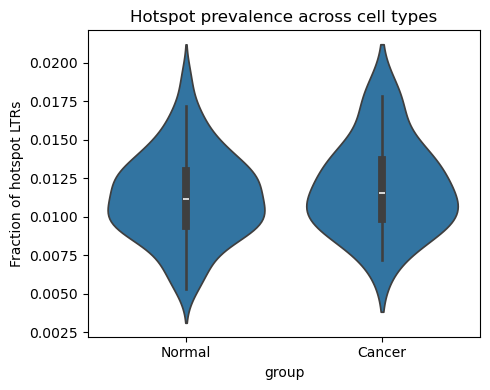

In [ ]:
# Quick visualization 

plt.figure(figsize=(5,4))

sns.violinplot(
    data=summary_per_cell,
    x="group",
    y="hotspot_fraction",
    inner="box"
)

plt.ylabel("Fraction of hotspot LTRs")
plt.title("Hotspot prevalence across cell types")

plt.tight_layout()
plt.show()

In [8]:
from scipy.stats import mannwhitneyu

normal = summary_per_cell[summary_per_cell["group"]=="Normal"]["hotspot_fraction"]
cancer = summary_per_cell[summary_per_cell["group"]=="Cancer"]["hotspot_fraction"]

stat, p = mannwhitneyu(normal, cancer)

print("p-value:", p)

p-value: 0.4877743422013622


In [9]:
print(summary_per_cell.groupby("group")["hotspot_fraction"].describe())

        count      mean       std       min       25%       50%       75%  \
group                                                                       
Cancer   16.0  0.011955  0.002900  0.007168  0.009841  0.011563  0.013704   
Normal  111.0  0.011333  0.002844  0.005337  0.009407  0.011162  0.012953   

             max  
group             
Cancer  0.017861  
Normal  0.018968  


In [10]:
print(summary_per_cell.groupby("group")["hotspot_fraction"].mean())

group
Cancer    0.011955
Normal    0.011333
Name: hotspot_fraction, dtype: float64


##### For each LTR locus:
across all cell types:
 - how often is it hotspot?

In [11]:
ltr_variability = (
    df.groupby(["chrom", "start", "end", "name"])
    .agg(
        hotspot_freq=("is_hotspot", "mean"),
        n_celltypes=("is_hotspot", "size")
    )
    .reset_index()
)

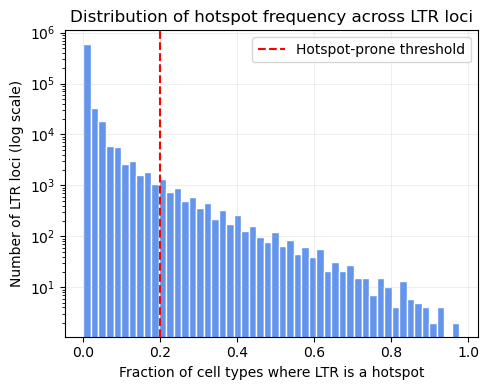

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))

ltr_variability["hotspot_freq"].hist(
    bins=50,
    log=True,
    color="cornflowerblue",
    edgecolor="white"
)

plt.xlabel("Fraction of cell types where LTR is a hotspot")
plt.ylabel("Number of LTR loci (log scale)")
plt.title("Distribution of hotspot frequency across LTR loci")

plt.axvline(0.2, color="red", linestyle="--", label="Hotspot-prone threshold")
plt.grid(alpha=0.2)
plt.legend()

plt.tight_layout()
plt.show()

**So...Hotspot behavior is not random—it is locus-specific and heterogeneous**

-  LTRs exhibit heterogeneous chromatin dynamics, where a subset of loci repeatedly forms transition hotspots across cell types. 
- These patterns are not captured by global or local statistical features, suggesting higher-order regulatory structure.

In [24]:
ltr_variability["is_hotspot_prone"] = ltr_variability["hotspot_freq"] > 0.2

In [25]:
df = df.merge(ltr_variability[["chrom","start","end","name","hotspot_freq"]],
              on=["chrom","start","end","name"])

# Define “hotspot-prone LTRs”
df["is_hotspot_prone"] = df["hotspot_freq"] > 0.2

In [16]:
df.groupby("is_hotspot_prone")["entropy"].mean()

is_hotspot_prone
False    0.183103
True     1.296051
Name: entropy, dtype: float64

In [38]:
# make it log scale
df["entropy_log"] = np.log10(df["entropy"] + 1e-3)

/var/folders/13/_k644pzx7fx6m400h0j14_0h0000gn/T/ipykernel_67753/551533082.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


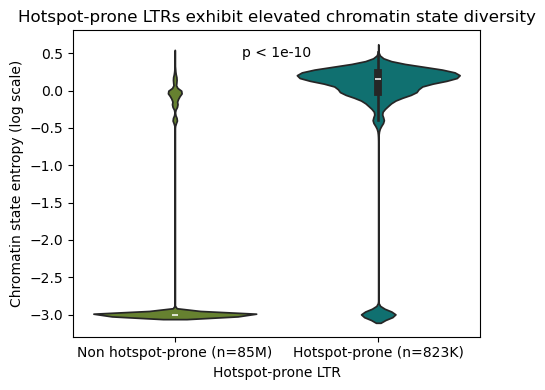

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

def format_n(n):
    if n >= 1_000_000:
        return f"{n/1_000_000:.0f}M"
    elif n >= 1_000:
        return f"{n/1_000:.0f}K"
    else:
        return str(n)

n_no = (df["is_hotspot_prone"] == False).sum()
n_yes = (df["is_hotspot_prone"] == True).sum()

palette = {
    "True": "teal",
    "False": "olivedrab"
}

plt.figure(figsize=(5,4))

sns.violinplot(
    data=df,
    x="is_hotspot_prone",
    y="entropy_log",
    palette=palette,
    inner="box"
)

plt.xlabel("Hotspot-prone LTR")
plt.ylabel("Chromatin state entropy (log scale)")
plt.title("Hotspot-prone LTRs exhibit elevated chromatin state diversity")

# plt.xticks([0,1], [f"Non hotspot-prone (n={n_no})", f"Hotspot-prone (n={n_yes})"])
plt.xticks(
    [0,1],
    [
        f"Non hotspot-prone (n={format_n(n_no)})",
        f"Hotspot-prone (n={format_n(n_yes)})"
    ]
)
plt.text(0.5, 0.45, "p < 1e-10", ha="center")

plt.tight_layout()
plt.show()

In [27]:
from scipy.stats import mannwhitneyu

group1 = df[df["is_hotspot_prone"]==False]["entropy"]
group2 = df[df["is_hotspot_prone"]==True]["entropy"]

stat, p = mannwhitneyu(group1, group2)
print("p-value:", p)

p-value: 0.0


In [43]:
df[["n_transitions", "entropy"]].corr()

,n_transitions,entropy
n_transitions,1.000000,0.911908
entropy,0.911908,1.000000


<Axes: xlabel='n_transitions', ylabel='entropy'>

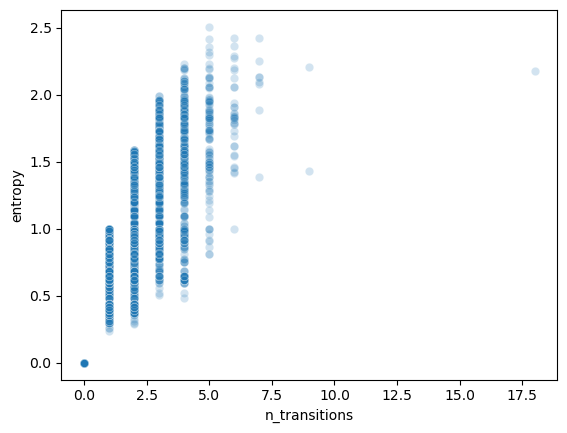

In [29]:
sns.scatterplot(
    data=df.sample(50000),
    x="n_transitions",
    y="entropy",
    alpha=0.2
)

In [32]:
df["entropy_norm"] = df["entropy"] / np.log(df["n_unique_states"].clip(lower=2))

In [33]:
df.head()

,cell_id,is_cancer,chrom,start,end,name,length,n_bins,O_ratio,n_transitions,...,frac_L,frac_M,frac_N,frac_O,is_hotspot,hotspot_freq_x,is_hotspot_prone,hotspot_freq_y,hotspot_freq,entropy_norm
0,E001,False,chr1,20948,23075,MLT1K,2127,12,1.0,0,...,0.0,0.0,0.0,1.0,False,0.0,False,0.0,0.0,-0.0
1,E001,False,chr1,29693,31848,MLT1A,2155,12,1.0,0,...,0.0,0.0,0.0,1.0,False,0.0,False,0.0,0.0,-0.0
2,E001,False,chr1,29952,32131,MLT1A,2179,12,1.0,0,...,0.0,0.0,0.0,1.0,False,0.0,False,0.0,0.0,-0.0
3,E001,False,chr1,33564,35921,MLT1J2,2357,13,1.0,0,...,0.0,0.0,0.0,1.0,False,0.0,False,0.0,0.0,-0.0
4,E001,False,chr1,37255,40464,MLT1E1A-int,3209,17,1.0,0,...,0.0,0.0,0.0,1.0,False,0.0,False,0.0,0.0,-0.0


##### 2. State/category enrichment in hotspot vs non-hotspot

##### 3. Three pairs: Do hotspot-prone LTRs undergo systematic remodeling during cancer transition?

In [47]:
import pandas as pd

df = pd.read_csv("../processed/ltr_feature_table.csv")
df["is_hotspot"] = df["n_transitions"] >= 4

In [48]:
df_pair = df[[
    "cell_id", "chrom", "start", "end", "name", "is_hotspot"
]].copy()

In [49]:
pairs = {
    "liver": ("E066", "E118"),
    "lung": ("E096", "E114"),
    "blood": ("E029", "E123"),
}

In [50]:
def make_hotspot_transition_table(df_pair, normal_id, cancer_id):
    df_normal = (
        df_pair[df_pair["cell_id"] == normal_id]
        .drop(columns=["cell_id"])
        .rename(columns={"is_hotspot": "hotspot_normal"})
    )

    df_cancer = (
        df_pair[df_pair["cell_id"] == cancer_id]
        .drop(columns=["cell_id"])
        .rename(columns={"is_hotspot": "hotspot_cancer"})
    )

    merged = df_normal.merge(
        df_cancer,
        on=["chrom", "start", "end", "name"],
        how="inner"
    )

    transition_table = pd.crosstab(
        merged["hotspot_normal"],
        merged["hotspot_cancer"]
    )

    transition_table.index = ["non-hotspot", "hotspot"]
    transition_table.columns = ["non-hotspot", "hotspot"]

    return merged, transition_table

In [51]:
merged_liver, table_liver = make_hotspot_transition_table(df_pair, "E066", "E118")
table_liver

,non-hotspot,hotspot
non-hotspot,654417,10267
hotspot,6085,1745


In [52]:
results = {}

for tissue, (normal_id, cancer_id) in pairs.items():
    merged, table = make_hotspot_transition_table(df_pair, normal_id, cancer_id)
    results[tissue] = {"merged": merged, "table": table}
    print(f"\n{tissue.upper()} ({normal_id} -> {cancer_id})")
    print(table)


LIVER (E066 -> E118)
             non-hotspot  hotspot
non-hotspot       654417    10267
hotspot             6085     1745

LUNG (E096 -> E114)
             non-hotspot  hotspot
non-hotspot       657114     8561
hotspot             6147      695

BLOOD (E029 -> E123)
             non-hotspot  hotspot
non-hotspot       650998     7139
hotspot             5669      849


In [53]:
# Row-normalized
for tissue in results:
    table = results[tissue]["table"]
    prop = table.div(table.sum(axis=1), axis=0)
    results[tissue]["prop_row"] = prop

    print(f"\n{tissue.upper()} row-normalized")
    print(prop)


LIVER row-normalized
             non-hotspot   hotspot
non-hotspot     0.984554  0.015446
hotspot         0.777139  0.222861

LUNG row-normalized
             non-hotspot   hotspot
non-hotspot     0.987139  0.012861
hotspot         0.898422  0.101578

BLOOD row-normalized
             non-hotspot   hotspot
non-hotspot     0.989153  0.010847
hotspot         0.869745  0.130255


In [54]:
def transition_labels(merged):
    out = merged.copy()
    out["transition"] = (
        out["hotspot_normal"].map({False: "non-hotspot", True: "hotspot"})
        + " → " +
        out["hotspot_cancer"].map({False: "non-hotspot", True: "hotspot"})
    )
    return out

liver_labeled = transition_labels(results["liver"]["merged"])
liver_labeled["transition"].value_counts()

transition
non-hotspot → non-hotspot    654417
non-hotspot → hotspot         10267
hotspot → non-hotspot          6085
hotspot → hotspot              1745
Name: count, dtype: int64

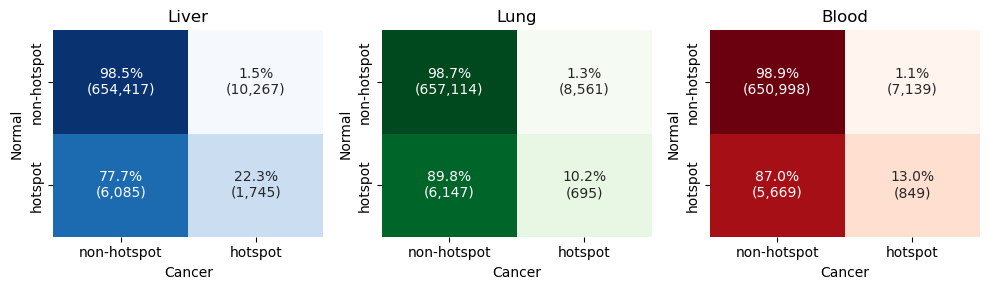

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(10,3))

# define colormap per tissue
cmap_dict = {
    "liver": "Blues",
    "lung": "Greens",
    "blood": "Reds"
}

for ax, (tissue, res) in zip(axes, results.items()):

    # build annotation: percentage (%) + count
    annot = res["prop_row"].copy().astype(str)

    for i in range(res["prop_row"].shape[0]):
        for j in range(res["prop_row"].shape[1]):
            p = res["prop_row"].iloc[i, j] * 100  # convert to %
            c = res["table"].iloc[i, j]          # raw count
            annot.iloc[i, j] = f"{p:.1f}%\n({c:,})"

    sns.heatmap(
        res["prop_row"],
        annot=annot,
        fmt="",
        cmap=cmap_dict[tissue],
        vmin=0,
        vmax=1,
        cbar=False,
        ax=ax
    )

    ax.set_title(tissue.capitalize())
    ax.set_xlabel("Cancer")
    ax.set_ylabel("Normal")

plt.tight_layout()
plt.show()